In [ ]:
!pip install prophet pandas matplotlib seaborn

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('monthly_sales.csv')

print("First 5 rows of the data:")
print(df.head())

print("\nData Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

First 5 rows of the data:
  year_month     category  total_sales  total_profit  total_quantity  \
0    2018-04     Clothing        13478          -184             251   
1    2018-04  Electronics        11127          -351              75   
2    2018-04    Furniture         8121         -3425              63   
3    2018-05     Clothing         9518          -267             233   
4    2018-05  Electronics        12807         -2523             116   

   order_count  
0           62  
1           22  
2           17  
3           71  
4           29  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   year_month      10 non-null     object
 1   category        10 non-null     object
 2   total_sales     10 non-null     int64 
 3   total_profit    10 non-null     int64 
 4   total_quantity  10 non-null     int64 
 5   order_count  

In [ ]:
monthly_total = df.groupby('year_month', as_index=False)['total_sales'].sum()
monthly_total = monthly_total.rename(columns={
    'year_month': 'ds',
    'total_sales': 'y'
})
monthly_total['ds'] = pd.to_datetime(monthly_total['ds'] + '-01')
print(monthly_total['ds'].unique())

print("Aggregated monthly total sales (first 5 rows):")
print(monthly_total.head())

print("\nData types after conversion:")
print(monthly_total.dtypes)

print("\nNumber of months in data:", len(monthly_total))

<DatetimeArray>
['2018-04-01 00:00:00', '2018-05-01 00:00:00', '2018-06-01 00:00:00',
 '2018-07-01 00:00:00']
Length: 4, dtype: datetime64[ns]
Aggregated monthly total sales (first 5 rows):
          ds      y
0 2018-04-01  32726
1 2018-05-01  28545
2 2018-06-01  23658
3 2018-07-01   2981

Data types after conversion:
ds    datetime64[ns]
y              int64
dtype: object

Number of months in data: 4


In [ ]:
print(df.columns.tolist())

['year_month', 'category', 'total_sales', 'total_profit', 'total_quantity', 'order_count']


In [ ]:
df = pd.read_csv('monthly_sales_clean.csv')

print("Column names:", df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

In [ ]:
import os
print("Files currently in Colab:")
print(os.listdir('.'))

In [ ]:
import pandas as pd

df = pd.read_csv('monthly_sales.csv')

print("Column names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Column names: ['year_month', 'category', 'total_sales', 'total_profit', 'total_quantity', 'order_count']

First 5 rows:
  year_month     category  total_sales  total_profit  total_quantity  \
0    2018-04     Clothing        13478          -184             251   
1    2018-04  Electronics        11127          -351              75   
2    2018-04    Furniture         8121         -3425              63   
3    2018-05     Clothing         9518          -267             233   
4    2018-05  Electronics        12807         -2523             116   

   order_count  
0           62  
1           22  
2           17  
3           71  
4           29  

Data types:
year_month        object
category          object
total_sales        int64
total_profit       int64
total_quantity     int64
order_count        int64
dtype: object


In [ ]:
monthly_total = df.groupby('year_month', as_index=False)['total_sales'].sum()

monthly_total = monthly_total.rename(columns={
    'year_month': 'ds',
    'total_sales': 'y'
})

monthly_total['ds'] = pd.to_datetime(monthly_total['ds'] + '-01')

monthly_total = monthly_total.sort_values('ds')

print("Prepared data for Prophet (first 5 rows):")
print(monthly_total.head())

print("\nData types now:")
print(monthly_total.dtypes)

print("\nNumber of months:", len(monthly_total))

Prepared data for Prophet (first 5 rows):
          ds      y
0 2018-04-01  32726
1 2018-05-01  28545
2 2018-06-01  23658
3 2018-07-01  12966
4 2018-08-01  30899

Data types now:
ds    datetime64[ns]
y              int64
dtype: object

Number of months: 12


INFO:prophet:n_changepoints greater than number of observations. Using 8.


Forecast preview (last 15 rows):
           ds           yhat     yhat_lower     yhat_upper
9  2019-01-01   61438.988919   61438.988915   61438.988923
10 2019-02-01   38424.010554   38424.010550   38424.010558
11 2019-03-01   58936.995866   58936.995862   58936.995870
12 2019-04-01   71748.342064   71744.936907   71751.751452
13 2019-05-01   95068.581871   95055.144750   95081.945936
14 2019-06-01   63632.841858   63616.321686   63648.981370
15 2019-07-01   36039.976619   36025.563756   36054.426542
16 2019-08-01   62871.132286   62837.102262   62905.666589
17 2019-09-01   51234.236572   51200.185122   51271.591294
18 2019-10-01   83084.340352   83016.805349   83160.101229
19 2019-11-01   87376.808249   87292.219595   87471.162020
20 2019-12-01   67084.737015   67011.978314   67169.125168
21 2020-01-01  131679.025839  131517.558129  131868.588223
22 2020-02-01   14005.771005   13986.823843   14028.462566
23 2020-03-01 -134685.175561 -134926.959636 -134486.516456


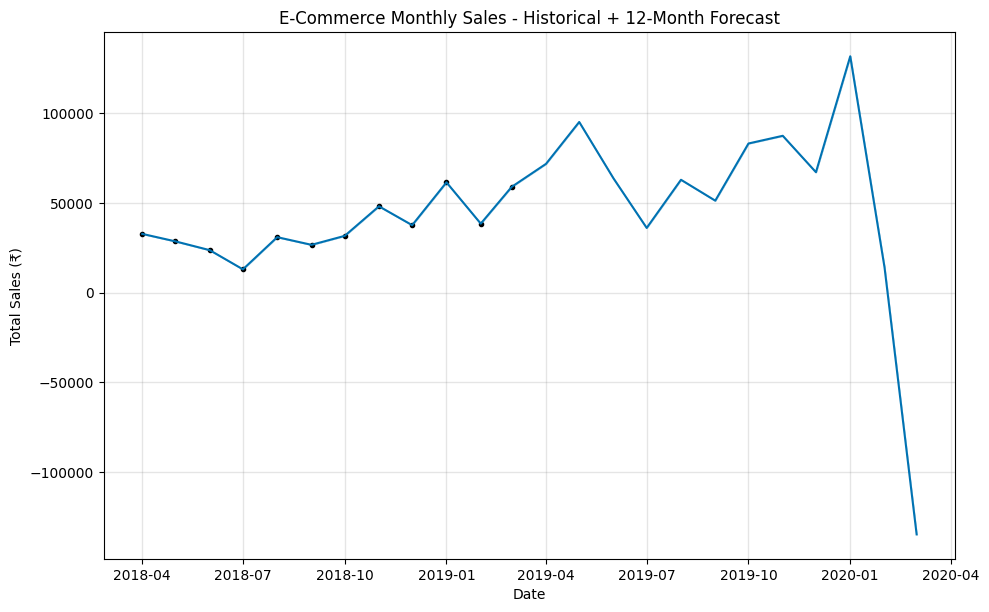

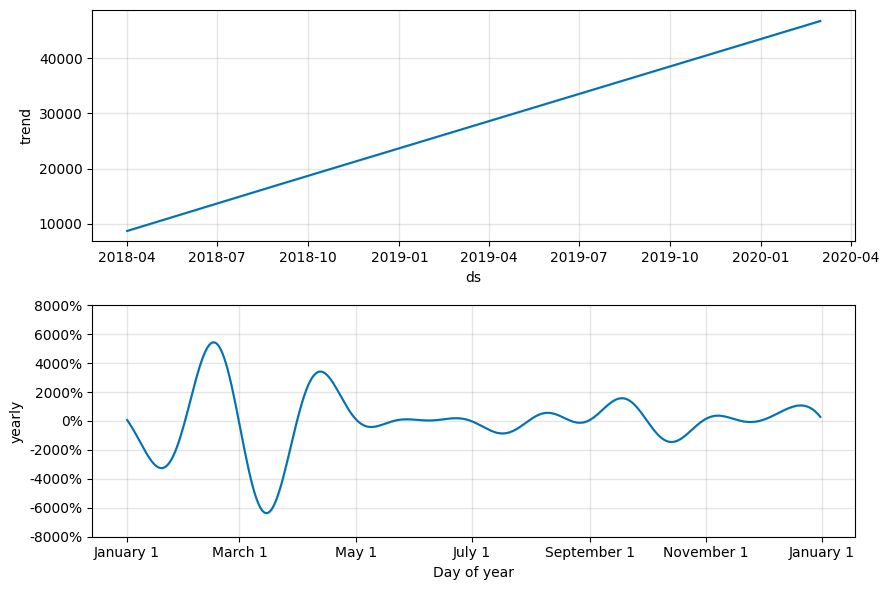

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative')

model.fit(monthly_total)
onths
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

print("Forecast preview (last 15 rows):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(15))

fig = model.plot(forecast)
plt.title("E-Commerce Monthly Sales - Historical + 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales (₹)")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('sales_forecast.csv', index=False)

print("Forecast saved as 'sales_forecast.csv' in Colab files!")
print("You can now download it from the left Files panel.")

Forecast saved as 'sales_forecast.csv' in Colab files!
You can now download it from the left Files panel.
